In [2]:
import numpy as np
import time
import pandas as pd
import time
from scipy import stats
import matplotlib.pyplot as plt
import os
import pulp
import networkx as nx

In [ ]:
def calcular_energia_total(s, A):
    
    # np.outer(s, s) genera la matriz de productos s_i * s_j
    # np.triu(A, k=1) extrae solo la parte triangular superior (las aristas J_ij sin duplicar)
    energia_interacciones = -np.sum(np.triu(A, k=1) * np.outer(s, s))
    
    energia_local = -np.sum(np.diag(A) * s)
    
    return energia_interacciones + energia_local

def intento_transicion_local(s, A, t, energia_actual):
    
    N = len(s)
    
    i = np.random.randint(0, N)
    
    # Calcular delta E usando la fórmula optimizada del informe
    # A[i, :] es la fila i (interacciones con otros vértices)
    # np.dot(A[i, :], s) es la suma (incluyendo el término A_ii * s_i, por lo que 
    # ajustamos sacando s_i y multiplicando por el s_i actual (antes del flip))

    suma_vecinos = np.dot(A[i, :], s) - A[i, i] * s[i]
    delta_E = 2 * s[i] * (A[i, i] + suma_vecinos)
    
    aceptado = False
    if delta_E <= 0:
        aceptado = True
    else:
        # Criterio de Metrópolis
        r = np.random.uniform(0, 1)
        if r <= np.exp(-delta_E / t):
            aceptado = True
            
    if aceptado:
        s[i] *= -1 
        energia_actual += delta_E
        
    return s, energia_actual, aceptado

def simulated_annealing(A, t_0, t_f, L, alpha):
   
    N = A.shape[0]
    s = np.random.choice([-1, 1], size=N) # Configuración inicial aleatoria
    energia_actual = calcular_energia_total(s, A)
    
    s_star = np.copy(s)
    energia_star = energia_actual
    
    t = t_0
    evaluaciones = 0
    
    while t >= t_f:
        for k in range(L):
            s, energia_actual, _ = intento_transicion_local(s, A, t, energia_actual)
            evaluaciones += 1
            
            if energia_actual < energia_star:
                energia_star = energia_actual
                s_star = np.copy(s)
                
        # Enfriamiento geométrico
        t *= alpha
        
    return s_star, energia_star, evaluaciones

def parallel_tempering(A, temperaturas, C, L):
    
    N = A.shape[0]
    M = len(temperaturas)
    

    s_replicas = [np.random.choice([-1, 1], size=N) for _ in range(M)]
    energias = [calcular_energia_total(s_replicas[i], A) for i in range(M)]
    
    # Encontrar la mejor inicial
    idx_mejor = np.argmin(energias)
    s_star = np.copy(s_replicas[idx_mejor])
    energia_star = energias[idx_mejor]
    
    evaluaciones_totales = 0
    
    for c in range(C):
        # Paso 1.1: Búsqueda intra-cadena (L iteraciones por réplica)
        for i in range(M):
            t_i = temperaturas[i]
            for _ in range(L):
                s_replicas[i], energias[i], _ = intento_transicion_local(s_replicas[i], A, t_i, energias[i])
                evaluaciones_totales += 1
                
                # Actualizar óptimo global
                if energias[i] < energia_star:
                    energia_star = energias[i]
                    s_star = np.copy(s_replicas[i])
                    
        # Paso 1.2: Intercambios inter-cadena (Swapping)
        for i in range(M - 1):
            delta_beta = (1.0 / temperaturas[i]) - (1.0 / temperaturas[i+1])
            delta_E = energias[i] - energias[i+1]
            
            # alfa de aceptación para el swap
            # delta_beta siempre es > 0 porque T_i < T_{i+1}. 
            # Si E_i > E_{i+1}, exp es positivo -> aceptamos (baja la energía hacia T más fría)
            exponente = delta_beta * delta_E
            
            # Prevenir overflow en np.exp
            if exponente > 0:
                alfa = 1.0 
            else:
                alfa = np.exp(exponente)
                
            r = np.random.uniform(0, 1)
            if r <= alfa:
                # Intercambiar las configuraciones y sus energías
                s_replicas[i], s_replicas[i+1] = s_replicas[i+1], s_replicas[i]
                energias[i], energias[i+1] = energias[i+1], energias[i]
                
    return s_star, energia_star, evaluaciones_totales


CALIBRACION DE PARAMETROS

In [17]:
def generar_escalera_geometrica(T_min, T_max, M):
    
    if M == 1:
        return [T_max]
    
    return np.geomspace(T_min, T_max, num=M)

def calibracion_parametros(lista_archivos_matrices):
    print(f"Iniciando calibración promediada sobre {len(lista_archivos_matrices)} instancias...")
    
    matrices = [np.load(archivo) for archivo in lista_archivos_matrices]
    
    N = matrices[0].shape[0] 
    
    L_opciones = [N, 2 * N]
    
    print("\n" + "="*65)
    print("CALIBRACIÓN PARA SIMULATED ANNEALING (SA)")
    print("="*65)
    
    t_0 = 10.0   
    t_f = 0.01  
    alphas = [0.85, 0.90, 0.95]
    
    for L in L_opciones:
        for alpha in alphas:
            energias = []
            tiempos = []
            evaluaciones = []
            
            for A in matrices:
                start = time.time()
                s_opt, E_opt, evals = simulated_annealing(A, t_0, t_f, L, alpha)
                tiempo = time.time() - start
                
                energias.append(E_opt)
                tiempos.append(tiempo)
                evaluaciones.append(evals)
                
            print(f"L={L:3d} | alpha={alpha:.2f} -> Energía Media: {np.mean(energias):7.2f} | Eval Media: {int(np.mean(evaluaciones)):6d} | Tiempo Medio: {np.mean(tiempos):.3f}s")

    print("\n" + "="*65)
    print("CALIBRACIÓN PARA PARALLEL TEMPERING (PT)")
    print("="*65)
    
    T_min = 0.1
    T_max = 10.0
    C_ciclos = 50 
    M_opciones = [5, 10, 15]
    
    for L in L_opciones:
        for M in M_opciones:
            temperaturas = generar_escalera_geometrica(T_min, T_max, M)
            
            energias = []
            tiempos = []
            evaluaciones = []
            
            for A in matrices:
                start = time.time()
                s_opt, E_opt, evals = parallel_tempering(A, temperaturas, C_ciclos, L)
                tiempo = time.time() - start
                
                energias.append(E_opt)
                tiempos.append(tiempo)
                evaluaciones.append(evals)
                
            print(f"L={L:3d} | M={M:2d} réplicas -> Energía Media: {np.mean(energias):7.2f} | Eval Media: {int(np.mean(evaluaciones)):6d} | Tiempo Medio: {np.mean(tiempos):.3f}s")


if __name__ == "__main__":
    
    archivos_prueba_100 = [
        "instancias_espin/matriz_A_mediano_N100_instancia1.npy",
        "instancias_espin/matriz_A_mediano_N100_instancia2.npy",
        "instancias_espin/matriz_A_mediano_N100_instancia3.npy",
        "instancias_espin/matriz_A_mediano_N100_instancia4.npy",
        "instancias_espin/matriz_A_mediano_N100_instancia5.npy",
        
    ]
    calibracion_parametros(archivos_prueba_100)


Iniciando calibración promediada sobre 5 instancias...

CALIBRACIÓN PARA SIMULATED ANNEALING (SA)
L=100 | alpha=0.85 -> Energía Media: -135.27 | Eval Media:   4300 | Tiempo Medio: 0.031s
L=100 | alpha=0.90 -> Energía Media: -136.59 | Eval Media:   6600 | Tiempo Medio: 0.048s
L=100 | alpha=0.95 -> Energía Media: -139.46 | Eval Media:  13500 | Tiempo Medio: 0.113s
L=200 | alpha=0.85 -> Energía Media: -138.59 | Eval Media:   8600 | Tiempo Medio: 0.073s
L=200 | alpha=0.90 -> Energía Media: -138.04 | Eval Media:  13200 | Tiempo Medio: 0.110s
L=200 | alpha=0.95 -> Energía Media: -141.48 | Eval Media:  27000 | Tiempo Medio: 0.218s

CALIBRACIÓN PARA PARALLEL TEMPERING (PT)
L=100 | M= 5 réplicas -> Energía Media: -138.93 | Eval Media:  25000 | Tiempo Medio: 0.179s
L=100 | M=10 réplicas -> Energía Media: -141.41 | Eval Media:  50000 | Tiempo Medio: 0.367s
L=100 | M=15 réplicas -> Energía Media: -141.66 | Eval Media:  75000 | Tiempo Medio: 0.539s
L=200 | M= 5 réplicas -> Energía Media: -139.95 | 

EXPERIMENTO 2

In [ ]:
def ejecutar_30_corridas(archivo_matriz):
    print(f"Cargando matriz para experimento principal: {archivo_matriz}")
    A = np.load(archivo_matriz)
    N = A.shape[0]
    
    CORRIDAS = 30
    L = N  
    
    # SA
    t_0_sa = 10.0
    t_f_sa = 0.01
    alpha_sa = 0.95
    
    # PT
    M_pt = 10
    C_pt = 50
    T_min_pt = 0.1
    T_max_pt = 10.0
    temps_pt = generar_escalera_geometrica(T_min_pt, T_max_pt, M_pt)
    
    # Listas para almacenar resultados
    resultados_sa = []
    resultados_pt = []
    
    print(f"\nIniciando las {CORRIDAS} corridas independientes...")
    
    for i in range(CORRIDAS):
        # --- Ejecutar SA ---
        start_sa = time.time()
        s_sa, E_sa, evals_sa = simulated_annealing(A, t_0_sa, t_f_sa, L, alpha_sa)
        tiempo_sa = time.time() - start_sa
        
        resultados_sa.append({
            "Corrida": i + 1,
            "Energia": E_sa,
            "Evaluaciones": evals_sa,
            "Tiempo_s": tiempo_sa
        })
        
        
        start_pt = time.time()
        s_pt, E_pt, evals_pt = parallel_tempering(A, temps_pt, C_pt, L)
        tiempo_pt = time.time() - start_pt
        
        resultados_pt.append({
            "Corrida": i + 1,
            "Energia": E_pt,
            "Evaluaciones": evals_pt,
            "Tiempo_s": tiempo_pt
        })
        
        # Pequeño log visual para saber que el script está avanzando
        if (i + 1) % 5 == 0:
            print(f"[{i + 1}/{CORRIDAS}] corridas completadas...")

    df_sa = pd.DataFrame(resultados_sa)
    df_pt = pd.DataFrame(resultados_pt)
    

    def calcular_metricas(df, nombre_algoritmo):
        mejor_eval = df["Energia"].min()
        media_eval = df["Energia"].mean()
        mediana_eval = df["Energia"].median()
        
        # La moda puede tener múltiples valores, tomamos el primero
        moda_eval_series = df["Energia"].mode()
        moda_eval = moda_eval_series[0] if not moda_eval_series.empty else np.nan
        
        costo_medio_tiempo = df["Tiempo_s"].mean()
        costo_medio_evals = df["Evaluaciones"].mean()
        
        print("\n" + "-"*40)
        print(f"ESTADÍSTICAS PARA {nombre_algoritmo}")
        print("-"*40)
        print(f"Mejor Evaluación (Mínima Energía): {mejor_eval:.2f}")
        print(f"Media de las Evaluaciones:         {media_eval:.2f}")
        print(f"Mediana de las Evaluaciones:       {mediana_eval:.2f}")
        print(f"Moda de las Evaluaciones:          {moda_eval:.2f}")
        print(f"Costo Computacional (Media Evals): {costo_medio_evals:.0f}")
        print(f"Tiempo Promedio por corrida:       {costo_medio_tiempo:.4f} s")
        
        # Calidad de la solución: qué tan estable es el algoritmo
        desviacion = df["Energia"].std()
        print(f"Desviación Estándar (Estabilidad): {desviacion:.2f}")
        
    calcular_metricas(df_sa, "SIMULATED ANNEALING (SA)")
    calcular_metricas(df_pt, "PARALLEL TEMPERING (PT)")
    
    df_sa.to_csv("resultados_SA_30corridas.csv", index=False)
    df_pt.to_csv("resultados_PT_30corridas.csv", index=False)
    print("\nResultados detallados guardados en CSV.")

if __name__ == "__main__":
    try:
        ejecutar_30_corridas("instancias_espin/matriz_A_mediano_N100.npy")
    except FileNotFoundError:
        print("Asegúrate de generar la matriz en el Paso 1.")

Cargando matriz para experimento principal: instancias_espin/matriz_A_mediano_N100.npy

Iniciando las 30 corridas independientes...
[5/30] corridas completadas...
[10/30] corridas completadas...
[15/30] corridas completadas...
[20/30] corridas completadas...
[25/30] corridas completadas...
[30/30] corridas completadas...

----------------------------------------
ESTADÍSTICAS PARA SIMULATED ANNEALING (SA)
----------------------------------------
Mejor Evaluación (Mínima Energía): -160.34
Media de las Evaluaciones:         -154.72
Mediana de las Evaluaciones:       -154.65
Moda de las Evaluaciones:          -160.34
Costo Computacional (Media Evals): 13500
Tiempo Promedio por corrida:       0.1399 s
Desviación Estándar (Estabilidad): 3.45

----------------------------------------
ESTADÍSTICAS PARA PARALLEL TEMPERING (PT)
----------------------------------------
Mejor Evaluación (Mínima Energía): -161.74
Media de las Evaluaciones:         -156.58
Mediana de las Evaluaciones:       -156.68


In [23]:
df_sa = pd.read_csv("resultados_SA_30corridas.csv")
df_pt = pd.read_csv("resultados_PT_30corridas.csv")


error_estandar_sa = df_sa["Energia"].std() / np.sqrt(30)
error_estandar_pt = df_pt["Energia"].std() / np.sqrt(30)

print(f"Error Estándar SA: {error_estandar_sa:.4f}")
print(f"Error Estándar PT: {error_estandar_pt:.4f}")

Error Estándar SA: 0.6304
Error Estándar PT: 0.4669


ESCALABILIDAD

In [9]:
def resolver_ple_exacto(matriz_A):
    
    N = matriz_A.shape[0]
    
    start_time = time.time()
    
    prob = pulp.LpProblem("Minima_Energia_Espin", pulp.LpMinimize)
    
    # x_i in {0, 1} para los nodos
    x = pulp.LpVariable.dicts("x", range(N), cat=pulp.LpBinary)
    
    # Identificar las aristas (solo miramos la parte triangular superior para no duplicar)
    aristas = []
    for i in range(N):
        for j in range(i + 1, N):
            if matriz_A[i, j] != 0:
                aristas.append((i, j))
                
    # y_ij in {0, 1} para la linealización de x_i * x_j
    y = pulp.LpVariable.dicts("y", aristas, cat=pulp.LpBinary)
    
    
    funcion_objetivo = []
    
    # Término de las interacciones (aristas)
    for (i, j) in aristas:
        J_ij = matriz_A[i, j]
        # -J_ij * (4*y_ij - 2*x_i - 2*x_j + 1)
        termino_arista = -J_ij * (4*y[i, j] - 2*x[i] - 2*x[j] + 1)
        funcion_objetivo.append(termino_arista)
        
    # Término de las influencias locales (nodos)
    for i in range(N):
        H_i = matriz_A[i, i]
        # -H_i * (2*x_i - 1)
        termino_nodo = -H_i * (2*x[i] - 1)
        funcion_objetivo.append(termino_nodo)
        
    prob += pulp.lpSum(funcion_objetivo), "Energia_Total"
    
    # restricciones (Linealización)
    for (i, j) in aristas:
        prob += y[i, j] <= x[i], f"Restriccion_y1_{i}_{j}"
        prob += y[i, j] <= x[j], f"Restriccion_y2_{i}_{j}"
        prob += y[i, j] >= x[i] + x[j] - 1, f"Restriccion_y3_{i}_{j}"
        

    prob.solve(pulp.PULP_CBC_CMD(msg=False))
    
    tiempo_ejecucion = time.time() - start_time
    
    # Mapear de vuelta de x_i (0 o 1) a s_i (-1 o 1)
    configuracion_optima = np.zeros(N)
    for i in range(N):
        valor_x = x[i].varValue
        configuracion_optima[i] = 2 * valor_x - 1
        
    energia_minima = pulp.value(prob.objective)
    
    return configuracion_optima, energia_minima, tiempo_ejecucion


if __name__ == "__main__":
    try:
        A_prueba = np.load("instancias_espin/matriz_A_pequeno_N10.npy")
        
        s_optimo, E_min, tiempo = resolver_ple_exacto(A_prueba)
        
        print("RESULTADOS DEL PLE")
        print(f"Energía mínima encontrada: {E_min:.4f}")
        print(f"Configuración óptima (s): {s_optimo}")
        print(f"Tiempo de ejecución: {tiempo:.4f} segundos")
        
    except FileNotFoundError:
        print("genera la matriz A")

RESULTADOS DEL PLE
Energía mínima encontrada: -11.8664
Configuración óptima (s): [ 1. -1. -1.  1.  1.  1.  1.  1. -1.  1.]
Tiempo de ejecución: 0.0922 segundos


In [16]:
def generar_matriz_A(N, sigma_J=1.0, sigma_H=1.0, semilla=None):
    
    if semilla is not None:
        np.random.seed(semilla)
        
    if N % 2 != 0:
        raise ValueError("El número de nodos N debe ser par.")
        
    G = nx.random_regular_graph(d=3, n=N, seed=semilla)
    
    A = np.zeros((N, N))
    
    for i in range(N):
        A[i, i] = np.random.normal(0, sigma_H)
        
    for u, v in G.edges():
        peso_J = np.random.normal(0, sigma_J)
        A[u, v] = peso_J
        A[v, u] = peso_J 
        
    return A

Iniciando análisis de escalabilidad...

Evaluando dimensión N = 10...
  PLE Exacto -> Tiempo: 0.101s | Energía: -15.90
  SA -> Tiempo: 0.014s | Energía: -15.90
  PT -> Tiempo: 0.045s | Energía: -15.90

Evaluando dimensión N = 20...
  PLE Exacto -> Tiempo: 0.064s | Energía: -36.24
  SA -> Tiempo: 0.030s | Energía: -36.24
  PT -> Tiempo: 0.075s | Energía: -36.24

Evaluando dimensión N = 30...
  PLE Exacto -> Tiempo: 0.085s | Energía: -47.25
  SA -> Tiempo: 0.034s | Energía: -46.85
  PT -> Tiempo: 0.196s | Energía: -46.95

Evaluando dimensión N = 50...
  PLE Exacto -> Omitido (Explosión Combinatoria)
  SA -> Tiempo: 0.085s | Energía: -70.19
  PT -> Tiempo: 0.246s | Energía: -73.79

Evaluando dimensión N = 100...
  PLE Exacto -> Omitido (Explosión Combinatoria)
  SA -> Tiempo: 0.134s | Energía: -144.86
  PT -> Tiempo: 0.581s | Energía: -145.67

Evaluando dimensión N = 200...
  PLE Exacto -> Omitido (Explosión Combinatoria)
  SA -> Tiempo: 0.354s | Energía: -277.06
  PT -> Tiempo: 1.155s | 

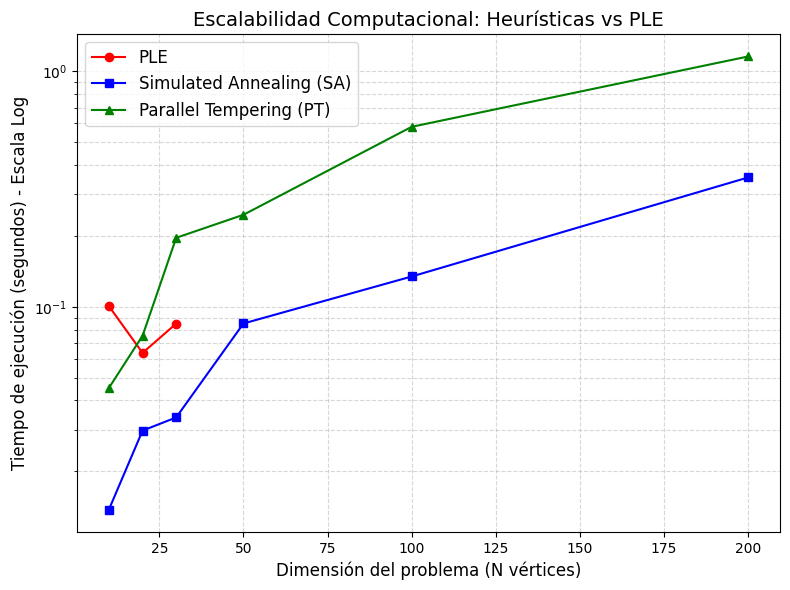

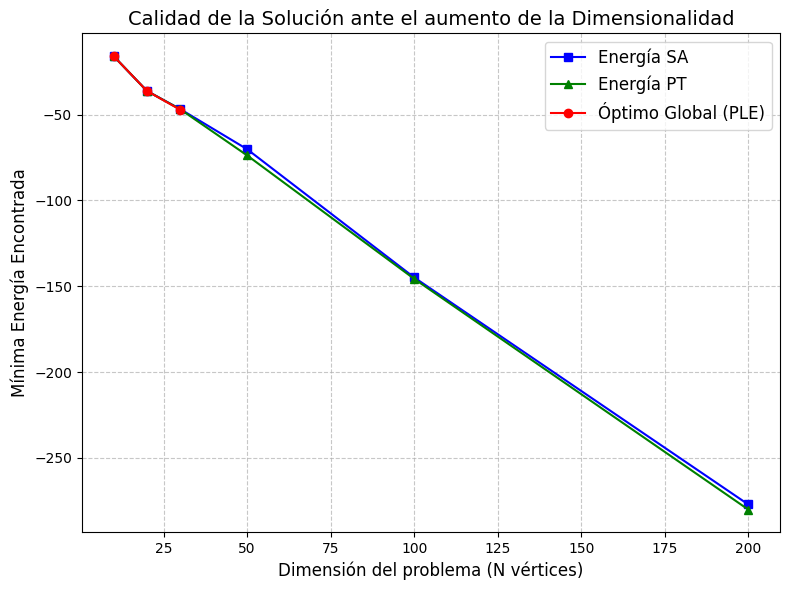

In [ ]:
def analisis_escalabilidad():
    # Definimos los tamaños de los grafos a evaluar
    tamaños_N = [10, 20, 30, 50, 100, 200,400,500]
    
    # Listas para almacenar los tiempos
    tiempos_ple = []
    tiempos_sa = []
    tiempos_pt = []
    
    # Listas para almacenar las energías encontradas (calidad)
    energias_ple = []
    energias_sa = []
    energias_pt = []
    
    # Parámetros fijos 
    L_ratio = 1 # L = N * L_ratio
    alpha_sa = 0.95
    M_pt = 10
    C_pt = 50
    temps_pt = generar_escalera_geometrica(0.1, 10.0, M_pt)
    
    print("Iniciando análisis de escalabilidad...")
    
    for N in tamaños_N:
        print(f"\nEvaluando dimensión N = {N}...")
        
        A = generar_matriz_A(N, sigma_J=1.0, sigma_H=1.0, semilla=N)
         
        if N <= 30:
            s_ple, E_ple, t_ple = resolver_ple_exacto(A)
            tiempos_ple.append(t_ple)
            energias_ple.append(E_ple)
            print(f"  PLE Exacto -> Tiempo: {t_ple:.3f}s | Energía: {E_ple:.2f}")
        else:
            tiempos_ple.append(None)
            energias_ple.append(None)
            print("  PLE Exacto -> Omitido (Explosión Combinatoria)")
            
        
        L = N * L_ratio
        start = time.time()
        s_sa, E_sa, _ = simulated_annealing(A, t_0=10.0, t_f=0.01, L=L, alpha=alpha_sa)
        t_sa = time.time() - start
        tiempos_sa.append(t_sa)
        energias_sa.append(E_sa)
        print(f"  SA -> Tiempo: {t_sa:.3f}s | Energía: {E_sa:.2f}")
        
        
        start = time.time()
        s_pt, E_pt, _ = parallel_tempering(A, temps_pt, C_pt, L)
        t_pt = time.time() - start
        tiempos_pt.append(t_pt)
        energias_pt.append(E_pt)
        print(f"  PT -> Tiempo: {t_pt:.3f}s | Energía: {E_pt:.2f}")

    
    os.makedirs("graficos", exist_ok=True)
    
    # Gráfico 1: Tiempo vs Dimensión (Escala Logarítmica)
    plt.figure(figsize=(8, 6))
    
    # Filtramos los None de PLE para graficar solo los valores calculados
    N_ple = [N for i, N in enumerate(tamaños_N) if tiempos_ple[i] is not None]
    t_ple_validos = [t for t in tiempos_ple if t is not None]
    
    plt.plot(N_ple, t_ple_validos, 'ro-', label='PLE')
    plt.plot(tamaños_N, tiempos_sa, 'bs-', label='Simulated Annealing (SA)')
    plt.plot(tamaños_N, tiempos_pt, 'g^-', label='Parallel Tempering (PT)')
    
    plt.yscale('log') 
    plt.xlabel('Dimensión del problema (N vértices)', fontsize=12)
    plt.ylabel('Tiempo de ejecución (segundos) - Escala Log', fontsize=12)
    plt.title('Escalabilidad Computacional: Heurísticas vs PLE', fontsize=14)
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.savefig('graficos/tiempo_vs_N.png', dpi=300)
    
    # Gráfico 2: Brecha de Calidad (Energía)
    # Calculamos la diferencia porcentual o absoluta respecto al mejor 

    plt.figure(figsize=(8, 6))
    plt.plot(tamaños_N, energias_sa, 'bs-', label='Energía SA')
    plt.plot(tamaños_N, energias_pt, 'g^-', label='Energía PT')
    
    if len(N_ple) > 0:
       
        energias_ple_validos = [e for e in energias_ple if e is not None]
        plt.plot(N_ple, energias_ple_validos, 'ro-', label='Óptimo Global (PLE)')
        
    plt.xlabel('Dimensión del problema (N vértices)', fontsize=12)
    plt.ylabel('Mínima Energía Encontrada', fontsize=12)
    plt.title('Calidad de la Solución ante el aumento de la Dimensionalidad', fontsize=14)
    plt.grid(True, ls="--", alpha=0.7)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.savefig('graficos/calidad_vs_N.png', dpi=300)
    
    print("\n¡Gráficos generados exitosamente en la carpeta 'graficos/'!")

if __name__ == "__main__":
    analisis_escalabilidad()